# Workforce Analytics: Optimizing Corporate Talent Pipelines
### Exploratory Data Analysis — Apex Global Innovations Inc. (HR Promotion Dataset)

**Objective:** Identify patterns in employee ratings, training, and demographics that
relate to promotion outcomes, and surface data-driven checkpoints HR can use to speed
up the evaluation cycle.

**Workflow:** Ingestion & Inspection → Cleaning → Univariate/Bivariate Profiling →
Multivariate Analysis → Insight Synthesis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('employee_promotion.csv')
df.shape

(54808, 13)

## Step 1 — Data Ingestion & Inspection

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 5.4 MB


In [3]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won                 0
avg_training_score      2560
is_promoted                0
dtype: int64

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate employee_id:", df['employee_id'].duplicated().sum())
df['is_promoted'].value_counts(normalize=True)

Duplicate rows: 0
Duplicate employee_id: 0


is_promoted
0    0.91483
1    0.08517
Name: proportion, dtype: float64

**Observation:** No duplicate records. Three columns have missing values:
`education` (2,409), `previous_year_rating` (4,124), `avg_training_score` (2,560).
The target `is_promoted` is heavily imbalanced — only ~8.5% of employees were promoted.
Any promotion-rate comparison across groups needs to be read as a *rate*, not a raw count.

## Step 2 — Data Cleaning & Missing Value Assessment

In [5]:
# Why is previous_year_rating missing? Check length_of_service for those rows.
df.loc[df['previous_year_rating'].isnull(), 'length_of_service'].describe()

count    4124.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: length_of_service, dtype: float64

**Key finding:** every single missing `previous_year_rating` belongs to an employee
with `length_of_service == 1`. This isn't random — brand-new employees simply haven't
had a performance review cycle yet. Imputing a mean/median rating here would fabricate
data that doesn't exist. Instead we flag these employees explicitly.

In [6]:
df['has_prior_rating'] = df['previous_year_rating'].notnull().astype(int)

# education: no strong missingness pattern found -> keep as an explicit category
# rather than guessing the mode, which would manufacture a false signal
df['education'] = df['education'].fillna('Unknown')

# avg_training_score: missingness concentrated in a few departments ->
# impute with the department median rather than the global median
df['avg_training_score'] = df.groupby('department')['avg_training_score']\
    .transform(lambda x: x.fillna(x.median()))

df[['education', 'previous_year_rating', 'avg_training_score']].isnull().sum()

education                  0
previous_year_rating    4124
avg_training_score         0
dtype: int64

## Step 3 — Univariate & Bivariate Profiling

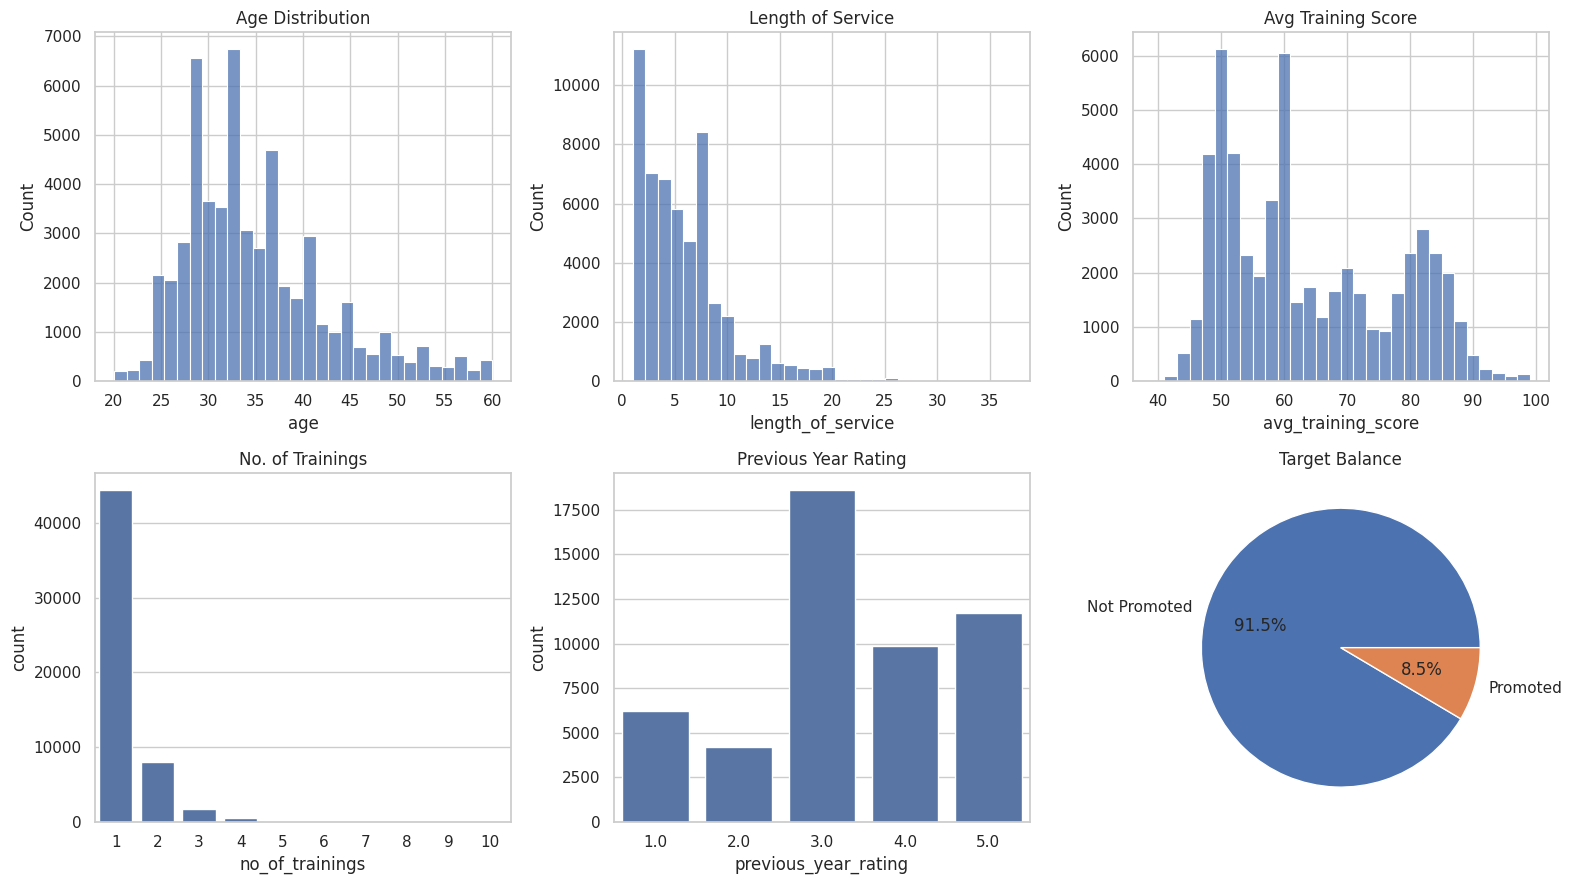

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['age'], bins=30, ax=axes[0,0]); axes[0,0].set_title('Age Distribution')
sns.histplot(df['length_of_service'], bins=30, ax=axes[0,1]); axes[0,1].set_title('Length of Service')
sns.histplot(df['avg_training_score'], bins=30, ax=axes[0,2]); axes[0,2].set_title('Avg Training Score')
sns.countplot(x='no_of_trainings', data=df, ax=axes[1,0]); axes[1,0].set_title('No. of Trainings')
sns.countplot(x='previous_year_rating', data=df, ax=axes[1,1]); axes[1,1].set_title('Previous Year Rating')
df['is_promoted'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1,2],
    labels=['Not Promoted','Promoted'], ylabel=''); axes[1,2].set_title('Target Balance')

plt.tight_layout(); plt.show()

In [8]:
promo_by_dept = df.groupby('department')['is_promoted'].agg(['mean','count'])\
    .sort_values('mean', ascending=False)
promo_by_dept

,mean,count
department,,
Technology,0.107593,7138
Procurement,0.096386,7138
Analytics,0.095665,5352
Operations,0.090148,11348
Finance,0.081230,2536
Sales & Marketing,0.072031,16840
R&D,0.069069,999
HR,0.056245,2418
Legal,0.051011,1039


**Departments:** Technology (10.8%), Procurement (9.6%) and Analytics (9.6%) promote
at the highest rates; Legal (5.1%) and HR (5.6%) are lowest. This is a ~2x spread purely
by department — worth investigating whether that reflects role structure/headcount growth
or inconsistent evaluation standards.

In [9]:
df.groupby('education')['is_promoted'].agg(['mean','count'])

,mean,count
education,,
Bachelor's,0.082031,36669
Below Secondary,0.083230,805
Master's & above,0.098559,14925
Unknown,0.050643,2409


In [10]:
df.groupby('awards_won')['is_promoted'].agg(['mean','count'])

,mean,count
awards_won,,
0,0.076749,53538
1,0.440157,1270


**Awards are the single strongest categorical signal**: employees who won a corporate
award were promoted at **44%**, versus **7.7%** for those who didn't — a >5x difference.

In [11]:
rated = df[df['has_prior_rating'] == 1]
rated.groupby('previous_year_rating')['is_promoted'].mean()

previous_year_rating
1.0    0.014141
2.0    0.042840
3.0    0.072779
4.0    0.079376
5.0    0.163615
Name: is_promoted, dtype: float64

**Prior rating relationship is not linear** — it's flat between ratings 1–4
(1.4% → 7.9%) and then jumps sharply at rating 5 (16.4%). A rating of 5 behaves almost
like a distinct "high potential" tier rather than a smooth continuum.

/tmp/ipykernel_971/449563118.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Promoted','Promoted']); axes[0].set_title('Training Score vs Promotion')
/tmp/ipykernel_971/449563118.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Promoted','Promoted']); axes[1].set_title('Length of Service vs Promotion')


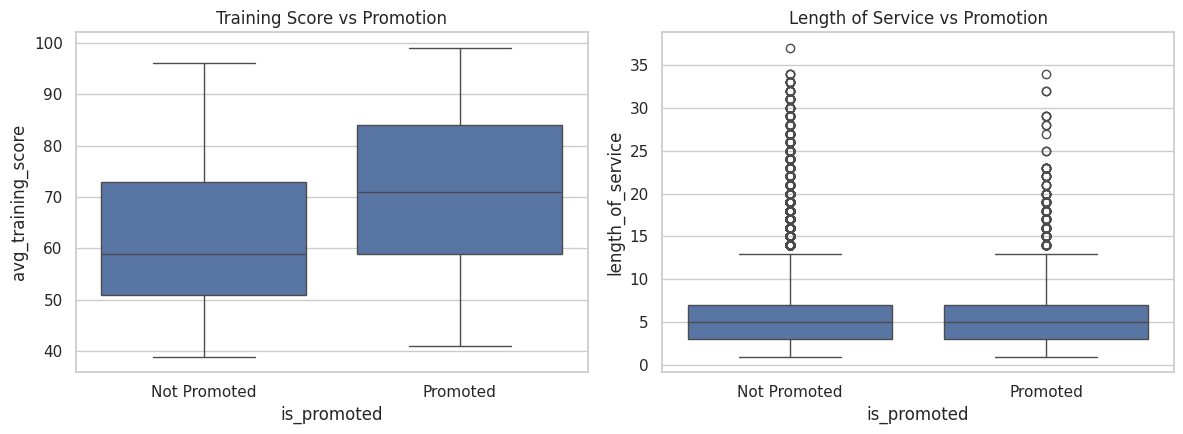

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x='is_promoted', y='avg_training_score', data=df, ax=axes[0])
axes[0].set_xticklabels(['Not Promoted','Promoted']); axes[0].set_title('Training Score vs Promotion')
sns.boxplot(x='is_promoted', y='length_of_service', data=df, ax=axes[1])
axes[1].set_xticklabels(['Not Promoted','Promoted']); axes[1].set_title('Length of Service vs Promotion')
plt.tight_layout(); plt.show()

**Length of service shows almost no separation** between promoted and non-promoted
employees — tenure alone is not a meaningful predictor here, which is a useful (if
counter-intuitive) finding for a promotion cycle that's currently manual and slow.

## Step 4 — Multivariate & Metric Analysis

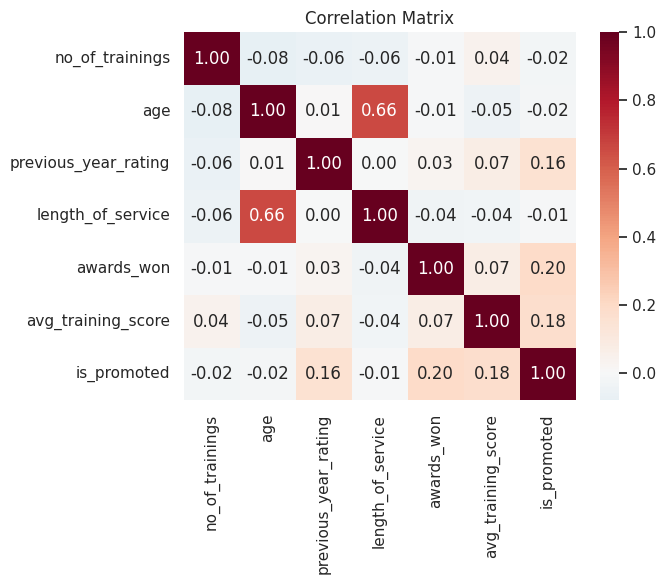

In [13]:
num_cols = ['no_of_trainings','age','previous_year_rating','length_of_service',
            'awards_won','avg_training_score','is_promoted']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
plt.title('Correlation Matrix'); plt.tight_layout(); plt.show()

**Age and length_of_service correlate strongly with each other (0.66)** — expected,
since tenure accumulates with age — but *neither* correlates with promotion (~-0.02).
What actually correlates with `is_promoted` are performance signals: `awards_won` (0.20),
`avg_training_score` (0.18), `previous_year_rating` (0.16). Demographics and tenure are
not driving outcomes here; performance metrics are.

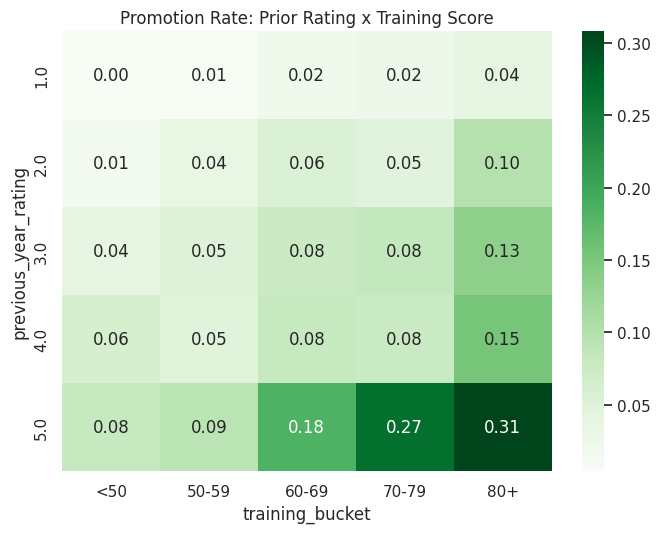

In [14]:
rated_bucketed = rated.copy()
rated_bucketed['training_bucket'] = pd.cut(
    rated_bucketed['avg_training_score'], bins=[0,50,60,70,80,100],
    labels=['<50','50-59','60-69','70-79','80+'])

pivot = rated_bucketed.pivot_table(index='previous_year_rating',
    columns='training_bucket', values='is_promoted', aggfunc='mean')

fig, ax = plt.subplots(figsize=(7,5.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Greens', ax=ax)
plt.title('Promotion Rate: Prior Rating x Training Score'); plt.tight_layout(); plt.show()

**This is the clearest checkpoint for HR.** Promotion rate climbs from **0%** for
low rating / low training combinations to **31%** for rating-5 + 80+ training score
employees. Rating and training score compound — an employee strong in only one of the
two rarely gets promoted; strong in both is where promotion becomes likely.

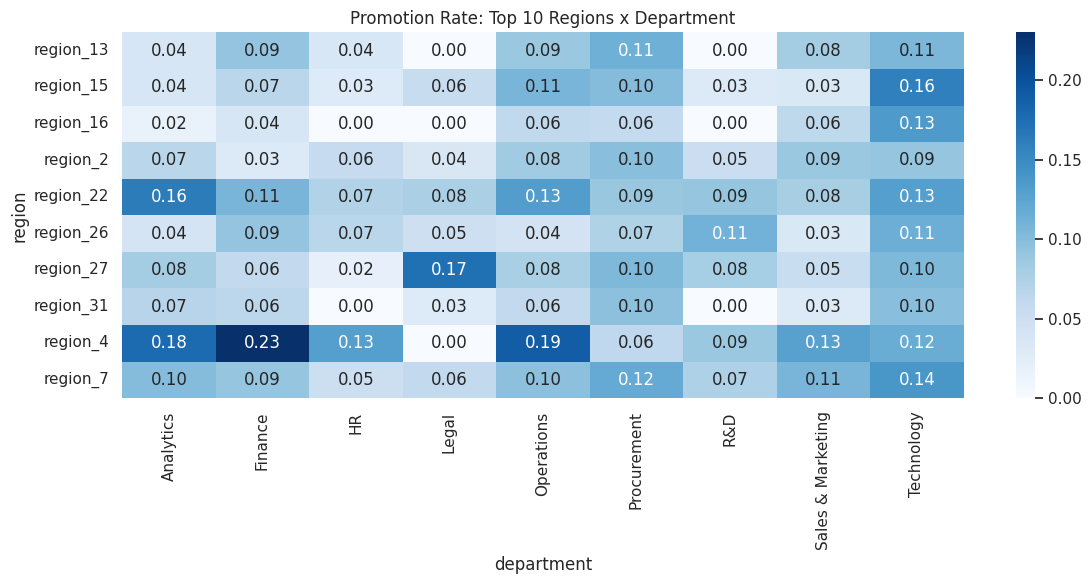

In [15]:
top_regions = df['region'].value_counts().head(10).index
region_dept = df[df['region'].isin(top_regions)].pivot_table(
    index='region', columns='department', values='is_promoted', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(region_dept, annot=True, fmt='.2f', cmap='Blues', ax=ax)
plt.title('Promotion Rate: Top 10 Regions x Department'); plt.tight_layout(); plt.show()

**Region x department shows uneven pockets** — some region/department combinations
promote 3-4x more than others even within the same department, suggesting local manager
discretion or team-level performance clusters rather than a uniform company-wide policy.

## Step 5 — Insight Synthesis & Recommendations

1. **Promotion is performance-driven, not tenure-driven.** Age and length_of_service
   are irrelevant to promotion despite being correlated with each other — HR can
   de-emphasize "years in role" as an evaluation criterion.
2. **Awards + training score + rating are the real signal.** A simple composite score
   from these three fields could serve as an automated first-pass filter, replacing
   part of the current manual review and directly addressing the "operational delay"
   problem stated in the brief.
3. **Rating 5 acts as a threshold, not a gradient.** Consider treating "rating 5" as a
   fast-track flag rather than one point on a 1–5 scale.
4. **New hires (`length_of_service == 1`) systematically lack a `previous_year_rating`.**
   Any promotion model or dashboard needs a separate track for first-year employees
   rather than treating their missing rating as "low."
5. **Department and region disparities (2x–4x spread) warrant an audit.** These may
   reflect legitimate differences in role structure, or inconsistent evaluation
   standards across regional managers — the data alone can't distinguish between the
   two, but it flags exactly where to look.
